# Machine Learning 지도학습 - 분류


## ⚙️환경설정


In [78]:
from lxml.includes.xmlerror import XML_TREE_INVALID_DEC
# scikit-learn 설치
!pip install scikit-learn

ModuleNotFoundError: No module named 'lxml.includes.xmlerror'

In [ ]:
import sklearn
sklearn.__version__

In [ ]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>


In [ ]:
# 도미와 빙어의 길이/무게 원자료

# 도미 bream 데이터 35개
# bream_length: 도미 35마리의 길이
# bream_weight: 도미 35마리의 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 smelt 데이터 14개
# smelt_length: 빙어 14마리의 길이
# smelt_weight: 빙어 14마리의 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [ ]:
# 산점도표를 이용해서 도미와 빙어의 분포를 확인
sns.scatterplot(
    x = bream_length,
    y = bream_weight,
    label = '도미'
)

sns.scatterplot(
    x = smelt_length,
    y = smelt_weight,
    label = '빙어'
)

plt.legend()
plt.show()

## KNN K-최근접이웃분류모델
데이터포인트간의 거리기반으로 분류를 수행하는 모델


### k-최근접 이웃 알고리즘 작동원리

최근접이웃(K-Nearest Neighbors, KNN)에서 거리를 구하는 방법으로 가장 일반적으로 사용되는 방법은 **유클리드 거리(Euclidean distance)**이다.

유클리드 거리란 "두 점 사이의 직선 거리" 를 구하는 가장 간단한 방법이다.

좌표상 (0, 0)과 (3, 4)라는 점 두 개를 찍었다고 하자. 이 두 점을 선으로 연결하면, 바로 그 선의 길이가 유클리드 거리이다!

$$\text { 거리 }=\sqrt{\left(x_{2}-x_{1}\right)^{2}+\left(y_{2}-y_{1}\right)^{2}}$$

두 점 $p = (p_1, p_2, ..., p_n)$과 $q = (q_1, q_2, ..., q_n)$ 사이의 유클리드 거리는 다음과 같은 수식으로 계산된다.

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}$$

#### 다양한 거리계산법
이 외에도 거리 계산에 사용하는 방법에는 **맨해튼 거리(Manhattan distance)**, **민코프스키 거리(Minkowski distance)**, **코사인 유사도(Cosine similarity)** 등이 있다.

1. 맨해튼 거리 계산식:

$$d(p, q) = |p_1 - q_1| + |p_2 - q_2| + \cdots + |p_n - q_n|$$

2. 민코프스키 거리 계산식(유클리드와 맨해튼 거리를 일반화한 형태):
  (여기서 $p = 2$일 때는 유클리드 거리, $p = 1$일 때는 맨해튼 거리이다)
$$d(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{1/p}$$

3. 코사인 유사도:
  (여기서 $p \cdot q$는 두 벡터의 내적, $\|p\|$와 $\|q\|$는 벡터의 크기이다)
$$\cos \theta = \frac{p \cdot q}{\|p\| \|q\|}$$



In [ ]:
# 도미와 빙어 데이터를 모델 입력용 데이터 X로 변환

# 도미와 빙어의 길이, 무게 list를 이어붙이기
fish_length = bream_length + smelt_length # 35+ 14 = 49개
fish_weight = bream_weight + smelt_weight

# print(len(fish_length), len(fish_weight))

fish_data = [[length, weight] for length, weight in zip(fish_length, fish_weight)]
fish_data = np.array(fish_data)
fish_data

In [ ]:
# fish_data에 대응되는 정답 y 만들기
# 앞에 도미 35마리를 1, 뒤에 빙어 14마리를 0으로
fish_target = np.array([1] * 35+ [0] * 14)
fish_target

In [79]:
# KNeighbors Classifier - KNN 분류 모델
# KNN은 새 데이터가 입력되면 가장 가까운 학습 데이터 이웃을 찾고
# 그 이웃들의 정답을 다수결로 사용해 새 데이터의 클래스를 판별함
from sklearn.neighbors import KNeighborsClassifier

# 입력된 값과 가장 가까운 이웃 5개를 보고 판별할 분류 모델 객체 생성
kn_clf = KNeighborsClassifier(n_neighbors=5)

| 항목 | 의미 |
|---|---|
| `n_neighbors = 5` | 가장 가까운 이웃 5개를 보고 판단 |
| `weights = 'uniform'` | 이웃 5개의 투표 가중치를 똑같이 적용 |
| `algorithm = 'auto'` | 가까운 이웃을 찾는 방법은 scikit-learn이 자동 선택 |
| `p = 2` | 거리 계산에서 유클리드 거리 사용 |
| `metric = 'minkowski'` | 민코프스키 거리 사용, `p=2`라서 사실상 유클리드 거리 |
| `n_jobs = None` | 병렬 처리 별도 지정 안 함 |

| 항목 | 의미 |
|---|---|
| `classes_ = [0, 1]` | 이 모델이 배운 정답 종류는 0과 1 |
| `n_features_in_ = 2` | 입력 feature는 2개, 즉 길이와 무게 |
| `n_samples_fit_ = 49` | 학습에 사용한 생선 데이터는 49개 |
| `outputs_2d_ = False` | 정답 `y`가 2차원이 아니라 1차원이라는 뜻 |

In [80]:
# KNN 분류 모델에 fish_data, fish_target 학습
# 모델.fit(data)

kn_clf.fit(fish_data, fish_target)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

KNeighborsClassifier()

In [81]:
# score()를 통해 분류 모델의 학습 정확도 점수를 반환(0~1 우수)

# - 학습에 사용한 데이터를 그대로 평가에 사용 == 당연히 1
kn_clf.score(fish_data, fish_target)

1.0

In [82]:
# 학습된 데이터 말고 새로운 데이터를 전달

# predict() : 학습된 모델로 새 데이터의 정답을 예측하는 메서드
# -입력은 반드시 2차원의 형태
sample = [[40, 500], [10,10], [11.3, 20], [15,200]]
kn_clf.predict(sample) # [1,0]으로 예측

array([1, 0, 0, 1])

In [83]:
# 새 데이터와 가장 가까운 이웃(이미 학습된 데이터) 찾기
# kneighbors(new, n_neighbors=k) : 새 데이터와 가장 가까운 이웃 k개 찾기
# 반환값 distances : 새 데이터와 가까운 이웃 사이의 거리
# 반환값 indices : 가까운 이웃들이 학습 데이터(fish_data)
#                 몇 번째 인덱스에 있는지 나타냄
distances, indices = kn_clf.kneighbors([[20,170]], n_neighbors=5)
print("distances: ", distances)
print("indices: ", indices)

fish_target[indices] # 이웃 목록 - 1(도미), 0(빙어)

distances:  [[ 72.20221603 120.1652612  150.18325473 150.408045   156.78431044]]
indices:  [[ 0  1 48 47 45]]


array([[1, 1, 0, 0, 0]])

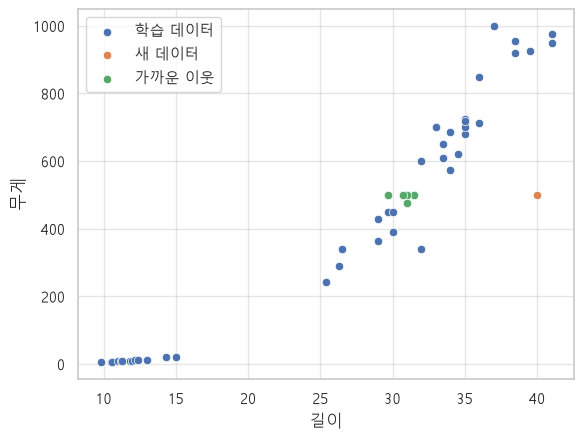

In [84]:
# 최근접 이웃을 시각화 (산점도)
sns.scatterplot(
    x = fish_data[:, 0], # 물고기 길이
    y = fish_data[:, 1], # 물고기 무게
    label = '학습 데이터'
)

# 새 데이터(예측하려는 데이터)를 그래프에 표시
sns.scatterplot(
    x = [40],
    y = [500],
    label = "새 데이터"

)

distances, indices = kn_clf.kneighbors([[40,500]], n_neighbors=5)
# 새 데이터와 가까운 이웃한 데이터의 인덱스를 5개 반환
# print(indices.squeeze()
neighbor_indices = indices.squeeze()

# 가까운 이웃한 데이터를 그래프에 표시
sns.scatterplot(
    x = fish_data[neighbor_indices , 0],
    y = fish_data[neighbor_indices , 1],
    label = '가까운 이웃'
)

plt.xlabel("길이")
plt.ylabel("무게")


plt.show()

## 학습/테스트 세트 분리


In [85]:
# 모든 데이터를 학습용 사용 X
# 일부는 학습, 일부는 테스트

# train_test_split() : 입력 X와 정답 y를 학습용/테스트용으로 분리
from sklearn.model_selection import train_test_split

(X_train, X_test, y_train, y_test) = train_test_split(
    fish_data, # X(문제)
    fish_target, # y(답)
    test_size = 0.2, # 전체 데이터 중 20%를 테스트용, 나머지 80% 학습용
    stratify = fish_target, # 도미, 빙어의 train/test 비율을 맞춤
    random_state = 42
)

print("X_train: ", X_train)
print("X_test: ", X_test.shape)
print("y_train: ", y_train)
print("y_test: ", y_test)


X_train:  [[  11.3    8.7]
 [  25.4  242. ]
 [  11.8    9.9]
 [  12.2   12.2]
 [  38.5  955. ]
 [  35.   725. ]
 [  32.   600. ]
 [  32.   340. ]
 [  35.   700. ]
 [  32.   600. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  33.5  650. ]
 [  33.5  610. ]
 [  30.   450. ]
 [  39.5  925. ]
 [  11.2    9.8]
 [  12.     9.8]
 [  36.   850. ]
 [  29.   363. ]
 [  30.7  500. ]
 [  31.5  500. ]
 [  14.3   19.7]
 [  31.   475. ]
 [  38.5  920. ]
 [   9.8    6.7]
 [  33.   700. ]
 [  10.5    7.5]
 [  36.   714. ]
 [  10.6    7. ]
 [  37.  1000. ]
 [  30.   390. ]
 [  33.   700. ]
 [  29.   430. ]
 [  13.    12.2]
 [  41.   975. ]
 [  15.    19.9]
 [  35.   720. ]
 [  34.5  620. ]]
X_test:  (10, 2)
y_train:  [0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 0
 1 1]
y_test:  [1 0 1 1 0 1 1 1 0 1]


In [86]:
# 1. 다시 KNN 분류 모델 생성
kn_clf = KNeighborsClassifier() # n_neighbors=5 기본값

# 2. X_train, y_train만 학습
kn_clf.fit(X_train, y_train)

# 3. 평가: X_test, y_test로 평가 점수 확인ㄴ
print(kn_clf.score(X_test, y_test))

# 4. 예측: X_test를 모델에 전달할 경우 얻는 예측값을 y_test와 비교
print("예측: ", kn_clf.predict(X_test))
print("정답: ", y_test)

1.0
예측:  [1 0 1 1 0 1 1 1 0 1]
정답:  [1 0 1 1 0 1 1 1 0 1]


## 수상한 도미
도미(길이 25, 무게 150)의 문제


In [87]:
kn_clf.predict([[25,150]])
# 실행 결과 : array([0]) == KNN 모델이 0 (빙어) 예측

array([0])

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]] [[ 1 36 22 34  3]]
[[1 0 0 0 0]]


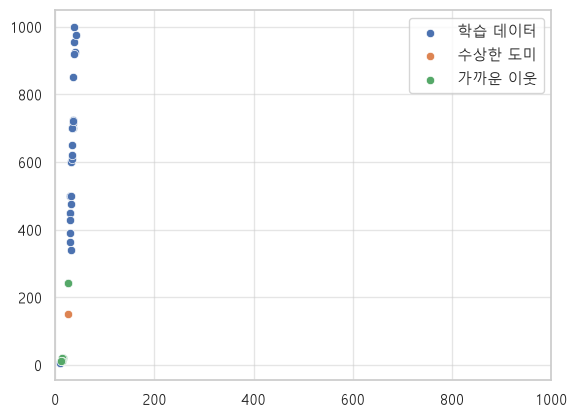

In [88]:
# 도미 데이터를 넣었는데 빙어로 예측하는 원인을 그래프로 확인
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], label='학습 데이터')
sns.scatterplot(x=[25], y=[150], label='수상한 도미')


# '수상한 도미'와 가장 가까운 이웃의 거리와 X_train 인덱스를 반환
distances, indices = kn_clf.kneighbors([[25, 150]])
print(distances, indices)

# 반환된 X_train 인덱스에 대응되는 정답 y_train 출력
print(y_train[indices])

neighbor_indices = indices.squeeze()
sns.scatterplot(
    x=X_train[neighbor_indices, 0],
    y=X_train[neighbor_indices, 1],
    label='가까운 이웃',
)


# x축 범위를 y축과 비슷하게 큰 값으로 설정함녀
# 분포가 함축되어 보여 구분하기가 쉬워진다! -> KNN에서 스케일링이 필요한 이유!
plt.xlim((0, 1000))
plt.legend()
plt.show()

## 표준점수-스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리기법.
모델 성능에 직접적인 영향이 있음.


###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.


In [89]:
# 사이킷런 제공 스케일링 전처리 클래스
# -> 각 feature(X)를 표준점수 z-score로 바꿔주는 전처리기
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 학습용/테스트용 입력 데이터(X)를 표준점수(z-score) 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링된 데이터를 fit() XXXXXXXXXXX
# -> 스케일링 안된 데이타 + 스케일링된 데이터 -> 학습 데이터가 엉망진창(누수)
# -> 대신 학습 데이터를 치환(변환) transform(X) 이용

print(X_test)
print(X_train_scaled)

[[ 26.3 290. ]
 [ 11.8  10. ]
 [ 34.  685. ]
 [ 31.  500. ]
 [ 12.4  13.4]
 [ 26.5 340. ]
 [ 35.  680. ]
 [ 34.  575. ]
 [ 11.    9.7]
 [ 41.  950. ]]
[[-1.58299969 -1.3623164 ]
 [-0.18349562 -0.64945483]
 [-1.53337188 -1.35864973]
 [-1.49366964 -1.35162194]
 [ 1.11675283  1.52915767]
 [ 0.76935821  0.82637944]
 [ 0.47159139  0.44443476]
 [ 0.47159139 -0.35001019]
 [ 0.76935821  0.74999051]
 [ 0.47159139  0.44443476]
 [ 0.24330349 -0.01389887]
 [ 0.24330349  0.13887901]
 [ 0.6204748   0.59721263]
 [ 0.6204748   0.47499033]
 [ 0.27308017 -0.01389887]
 [ 1.21600844  1.43749094]
 [-1.59292525 -1.35895528]
 [-1.51352076 -1.35895528]
 [ 0.86861382  1.20832413]
 [ 0.17382456 -0.27973237]
 [ 0.3425591   0.13887901]
 [ 0.42196358  0.13887901]
 [-1.28523287 -1.32870526]
 [ 0.37233578  0.06249007]
 [ 1.11675283  1.42221316]
 [-1.7318831  -1.36842751]
 [ 0.57084699  0.74999051]
 [-1.66240417 -1.36598306]
 [ 0.86861382  0.79276831]
 [-1.65247861 -1.36751084]
 [ 0.96786942  1.66665776]
 [ 0.2730801

In [90]:
# 새 KNN 분류 모델 만들어서 스케일링된 데이터로 재학습
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)
print("테스트 점수: ", kn_clf.score(X_test_scaled, y_test))

테스트 점수:  1.0


In [91]:
# 수상한 도미 [25,150] 데이터를 스케일링된 데이터를 학습한 모델에게 전달
# -> 수상한 도미 [25, 150]를 스케일링하여 전달!!
q = scaler.transform([[25,150]]) # z-score로 치환
print(q)
kn_clf.predict(q) # 스케일링 전 == 0, 스케일링 후 == 1

[[-0.22319787 -0.93056612]]


array([1])

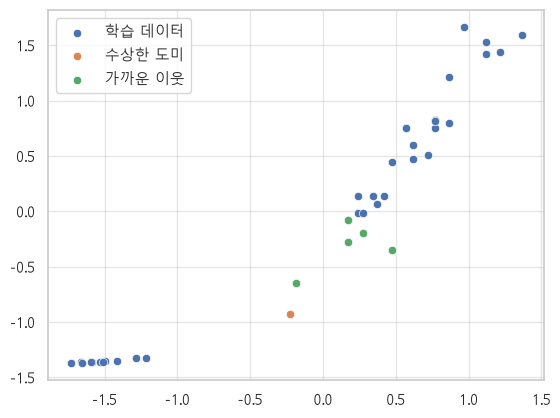

In [92]:
# X_train_scaled[:, 0]: 스케일링된 길이
# X_train_scaled[:, 1]: 스케일링된 무게
sns.scatterplot(x=X_train_scaled[:, 0], y=X_train_scaled[:, 1], label='학습 데이터')

sns.scatterplot(x=q[:, 0], y=q[:, 1], label='수상한 도미')

distances, indices = kn_clf.kneighbors(q)
neighbor_indices = indices.squeeze()

sns.scatterplot(
    x=X_train_scaled[neighbor_indices, 0],
    y=X_train_scaled[neighbor_indices, 1],
    label='가까운 이웃',
)

plt.legend()
plt.show()

# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.



In [93]:
# 데이터셋 불러오기"
fish_df = pd.read_csv("data/fish.csv")
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [94]:
# 데이터셋에 종 별로 몇 마리씩 이쓴지 확인
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [95]:
# 다중 분류 모델에 학습 시킬 입력 X, 정답 y를 분리
# X : 물고기의 수치 컬럼 5개를 담은 2차원 array
# y: 긱 믈고기의 종류 Species 담은 1차원 array
X = fish_df[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
y = fish_df['Species'].to_numpy()
print(X.shape, y.shape)

(159, 5) (159,)


In [96]:
# 다중 분류 train/test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = (
    train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42))

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(127, 5) (127,)
(32, 5) (32,)


In [97]:
# 입력 값 X의 데이터 단위를 표준화 -> 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 스케일러에게 입력 값 X를 학습 -> 내부적으로 평균, 표준편차가 계산됨
scaler.fit(X_train)

# 학습 데이터와 test 데이터를 같은 평균/표준편차를 이용해 스케일링
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-5.79927544e-01 -5.27828558e-01 -4.87545368e-01  3.09900763e-01
  -4.66326256e-01]
 [-1.14865496e+00 -1.68207324e+00 -1.69861632e+00 -1.63397471e+00
  -1.89772720e+00]
 [-9.38746102e-01 -9.19097940e-01 -9.93664570e-01 -7.98183071e-01
  -8.34253402e-01]
 [-4.54341049e-01 -2.93066929e-01 -1.07955966e-01  5.86145357e-01
  -2.52551827e-01]
 [ 8.70297460e-01  5.48162242e-01  7.23525581e-01  1.63861326e+00
   5.57439726e-01]
 [ 9.15149779e-01  4.50344897e-01  6.60260681e-01  1.39027074e+00
   4.53731536e-01]
 [ 3.17118850e-01  3.03618879e-01  4.70465980e-01  1.11294394e+00
  -4.38158518e-02]
 [-8.49041463e-01 -7.23463249e-01 -7.85794184e-01 -7.84843718e-01
  -5.31466276e-01]
 [ 7.65642047e-01  1.03724897e+00  9.22358125e-01  4.95945921e-01
   9.36883340e-01]
 [-2.80912080e-01 -1.07213972e-01 -2.25447924e-01 -1.65987131e-01
   4.17622612e-01]
 [-8.19139916e-01 -7.23463249e-01 -6.77340069e-01 -6.85539645e-01
  -6.87838312e-01]
 [-1.05835229e+00 -1.39840293e+00 -1.35517829e+00 -1.14839403e+00

In [98]:
# KNN 다중 분류 학습
from sklearn.neighbors import KNeighborsClassifier

# 가까운 이웃 3개를 보고 정답을 예측(다수결)
kn_clf = KNeighborsClassifier(n_neighbors=3)

# 학습
kn_clf.fit(X_train_scaled, y_train)

kn_clf.get_params()
print(kn_clf.classes_)
print(kn_clf.n_neighbors)
print(kn_clf.n_samples_fit_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
3
127


In [101]:
print("학습 점수: ", kn_clf.score(X_train_scaled, y_train))
print("테스트 평가 점수: ", kn_clf.score(X_test_scaled, y_test))

print("예측: ", kn_clf.predict(X_test_scaled))
print("정답: ", y_test)

학습 점수:  0.889763779527559
테스트 평가 점수:  0.8125
예측:  ['Bream' 'Roach' 'Smelt' 'Perch' 'Perch' 'Perch' 'Bream' 'Pike' 'Smelt'
 'Perch' 'Roach' 'Perch' 'Parkki' 'Perch' 'Pike' 'Perch' 'Bream' 'Perch'
 'Perch' 'Pike' 'Roach' 'Bream' 'Perch' 'Perch' 'Bream' 'Bream' 'Parkki'
 'Perch' 'Perch' 'Perch' 'Pike' 'Bream']
정답:  ['Bream' 'Roach' 'Smelt' 'Perch' 'Perch' 'Perch' 'Bream' 'Pike' 'Smelt'
 'Perch' 'Whitefish' 'Roach' 'Parkki' 'Perch' 'Pike' 'Roach' 'Bream'
 'Perch' 'Perch' 'Pike' 'Perch' 'Bream' 'Smelt' 'Roach' 'Bream' 'Bream'
 'Parkki' 'Perch' 'Perch' 'Perch' 'Pike' 'Bream']


In [103]:
# KNN 이 학습 후 어떤 정보를 가지고 있나 확인
print(kn_clf.classes_)

print(kn_clf._fit_X)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[-5.79927544e-01 -5.27828558e-01 -4.87545368e-01  3.09900763e-01
  -4.66326256e-01]
 [-1.14865496e+00 -1.68207324e+00 -1.69861632e+00 -1.63397471e+00
  -1.89772720e+00]
 [-9.38746102e-01 -9.19097940e-01 -9.93664570e-01 -7.98183071e-01
  -8.34253402e-01]
 [-4.54341049e-01 -2.93066929e-01 -1.07955966e-01  5.86145357e-01
  -2.52551827e-01]
 [ 8.70297460e-01  5.48162242e-01  7.23525581e-01  1.63861326e+00
   5.57439726e-01]
 [ 9.15149779e-01  4.50344897e-01  6.60260681e-01  1.39027074e+00
   4.53731536e-01]
 [ 3.17118850e-01  3.03618879e-01  4.70465980e-01  1.11294394e+00
  -4.38158518e-02]
 [-8.49041463e-01 -7.23463249e-01 -7.85794184e-01 -7.84843718e-01
  -5.31466276e-01]
 [ 7.65642047e-01  1.03724897e+00  9.22358125e-01  4.95945921e-01
   9.36883340e-01]
 [-2.80912080e-01 -1.07213972e-01 -2.25447924e-01 -1.65987131e-01
   4.17622612e-01]
 [-8.19139916e-01 -7.23463249e-01 -6.77340069e-01 -6.85539645e-01
  -6.87838312e-01]
 [-

In [108]:
print(X_test_scaled.shape)

(32, 5)


In [110]:
# print(X_test_scaled[:5]) # X_test_scaled 0~4번째 행

# 테스트 데이터 앞 5행만 예측하고 정답과 비교
print(kn_clf.predict(X_test_scaled[:5]))
print(y_test[:5])

['Bream' 'Roach' 'Smelt' 'Perch' 'Perch']
['Bream' 'Roach' 'Smelt' 'Perch' 'Perch']


In [111]:
# 예측 확률 확인
print(kn_clf.predict_proba(X_test_scaled[:5]))

[[1.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.33333333 0.         0.66666667 0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.66666667 0.         0.         0.
  0.33333333]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


In [114]:
# 다중 분류에서 kneighbor()로 예측 근거가 된 이웃 찾기
distances, indices = kn_clf.kneighbors(X_test_scaled[:1])
print(X_test_scaled[0])
print(distances, indices)

print(y_train[indices])

[1.36367298 0.74379693 0.94043381 1.84940798 1.05408739]
[[0.43414966 0.46522533 0.48136003]] [[101  50  26]]
[['Bream' 'Bream' 'Bream']]


## @실습문제: 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)


In [117]:
# scikit-learn 에서 iris 데이터셋 얻어오기
from sklearn.datasets import load_iris

iris = load_iris()
# print(iris.data) # 입력 X
# print(iris.target) # 정답 y
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [121]:
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
iris_df['target'] = iris.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [129]:
# 1. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, stratify = iris.target, random_state = 42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 2. 스케일링
scaler = StandardScaler()

scaler.fit(X_train) # X_train 기준 평균, 표준편차 학습

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. KNN 분류 모델 생성 + 학습 fit()
kn_clf = KNeighborsClassifier(n_neighbors=3)
kn_clf.fit(X_train_scaled, y_train)

# 4. 평가
print("학습 데이터셋 평가: ", kn_clf.score(X_train_scaled, y_train))
print("테스트 데이셧셋 평가: ", kn_clf.score(X_test_scaled, y_test))

# 5. 예측 predict() - test 데이터 일부와 실제 정답을 비교
print("예측: ", kn_clf.predict(X_test_scaled[:5]))
print('정답: ', y_test[:5])

(112, 4) (112,)
(38, 4) (38,)
학습 데이터셋 평가:  0.9642857142857143
테스트 데이셧셋 평가:  0.9210526315789473
예측:  [0 1 1 1 0]
정답:  [0 1 1 1 0]
